In [95]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
    
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1
    
from scipy.ndimage import filters as filt
def filtr(var, n):
   return filt.uniform_filter(var,n,None,'mirror',0)

from scipy.interpolate import griddata

def griddata_matlab(lona,lata,ugos,lon_rho,lat_rho):
    points = np.column_stack((lona.ravel(), lata.ravel()))
    values = ugos.ravel()
    
    # 步骤2: 创建目标网格点
    target_points = np.column_stack((lon_rho.ravel(), lat_rho.ravel()))
    
    # 步骤3: 执行插值
    ugos_interp = griddata(points, values, target_points, method='linear')
    
    # 步骤4: 重塑为原始网格形状
    ugos_interp = ugos_interp.reshape(lon_rho.shape)
    return ugos_interp

def snake_scan(matrix):
    """
    ravel() for particles
    matrix: 
        
    flat_array: 1d arrays
    """
    rows, cols = matrix.shape
    result = []
    
    for i in range(rows):
        if i % 2 == 0:  # 偶数行：从左到右
            result.extend(matrix[i, :])
        else:           # 奇数行：从右到左
            result.extend(matrix[i, ::-1])
    
    return np.array(result)

import numpy as np
from scipy.interpolate import griddata

def particle_roughdistr_onetime(lonp, latp, cI, cJ, NP, Range, shape='circle'):
    '''    
    para:
        lonp, latp: grid
        cI, cJ: center of region
        NP: numbers of p
        Range: sub region
        shape:  ('box' or 'circle')
    '''
    squareP = int(np.sqrt(NP))
    Len = int(Range)
    
    # 
    if Len % 2 == 0:
        II = [int(cI - Len/2), int(cI + Len/2)]
        JJ = [int(cJ - Len/2), int(cJ + Len/2)]
    else:
        II = [int(cI - (Len+1)/2), int(cI + Len/2)]
        JJ = [int(cJ - (Len+1)/2), int(cJ + Len/2)]
    
    # sub region
    lonp1 = lonp[JJ[0]:JJ[1], II[0]:II[1]]
    latp1 = latp[JJ[0]:JJ[1], II[0]:II[1]]
    
    # 
    Iin, Jin = np.meshgrid(np.arange(lonp1.shape[0]), 
                          np.arange(lonp1.shape[1]))
    
    points = np.column_stack((Iin.ravel(), Jin.ravel()))

    # choose shape
    if shape == 'box':
        # 
        I1 = np.linspace(0, lonp1.shape[0]-1, squareP)
        J1 = np.linspace(0, lonp1.shape[1]-1, squareP)
        I11, J11 = np.meshgrid(I1, J1)
        
        # 
        lonp2 = griddata(points, lonp1.ravel(), (I11, J11), method='linear')
        latp2 = griddata(points, latp1.ravel(), (I11, J11), method='linear')
        return snake_scan(lonp2), snake_scan(latp2)
    
    elif shape == 'circle':

        center_x = lonp1.shape[0] / 2
        center_y = lonp1.shape[1] / 2
        
        radius = min(lonp1.shape[0], lonp1.shape[1]) / 2
        
        r = radius * np.sqrt(np.random.rand(NP))  #
        theta = 2 * np.pi * np.random.rand(NP)
        
        # 
        x = center_x + r * np.cos(theta)
        y = center_y + r * np.sin(theta)
        
        # 
        points_target = np.column_stack((x, y))
        lonp2 = griddata(points, lonp1.ravel(), points_target, method='linear')
        latp2 = griddata(points, latp1.ravel(), points_target, method='linear')
        
        return lonp2, latp2



def generate_release_times_hourly(total_particles, particles_per_hour, start_time=0):
    """
    :
        total_particles: 
        particles_per_hour: 
        start_time: 
    :
        timep2: 
    """
    total_particles = int(total_particles)
    particles_per_hour = int(particles_per_hour)

    hours_needed = int(np.ceil(total_particles / particles_per_hour))

    timep2 = []
    for hour in range(hours_needed):
        particles_this_hour = min(particles_per_hour, total_particles - len(timep2))
        hour_start = start_time + hour * 3600
        timep2.extend([hour_start] * particles_this_hour)
    
    return np.array(timep2)


# check $u^{E}$ in hf case

In [4]:
input_dir='/meddy/simingzhang/Data/RB_iceland_data/'
grdname='niskin2km_500m_grd.nc'
eddywavename='eddyWave.0002.nc'

grid=xr.open_dataset(f'{input_dir}{grdname}')
ds=xr.open_dataset(f'{input_dir}/iceland_wave/{eddywavename}')

In [6]:
lonr=grid['lon_rho'].values
latr=grid['lat_rho'].values

In [65]:
uE=np.squeeze(ds['uEddy'].values)
vE=np.squeeze(ds['vEddy'].values)
uW=np.squeeze(ds['uWave'].values)
vW=np.squeeze(ds['vWave'].values)

In [66]:
u_EG=np.zeros((2147,287,287))
v_EG=np.zeros((2147,287,287))
u_WG=np.zeros((2147,287,287))
v_WG=np.zeros((2147,287,287))

In [67]:
for tin in range(2147):
    # print(i)
    # n=5 ~ 15*2km ~ 30km
    n=10
    u_EG[tin,:,:]=filtr(uE[tin,:,:],n)
    v_EG[tin,:,:]=filtr(vE[tin,:,:],n)

    u_WG[tin,:,:]=filtr(uW[tin,:,:],n)
    v_WG[tin,:,:]=filtr(vW[tin,:,:],n)

/tmp/ipykernel_126378/522856217.py:111: DeprecationWarning: Please import `uniform_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  return filt.uniform_filter(var,n,None,'mirror',0)


In [68]:
ke_E=0.5*(uE**2+vE**2)
ke_W=0.5*(uW**2+vW**2)
ke_EG=0.5*(u_EG**2+v_EG**2)
ke_WG=0.5*(u_WG**2+v_WG**2)
del uE,vE,uW,vW

In [86]:
# from matplotlib.gridspec import GridSpec
# colors={'#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf'}
# from cmocean import cm

# fig2 = plt.figure(figsize=(10, 10))
# gs = GridSpec(2, 2, figure=fig2)
# ax2 = [
#     [fig2.add_subplot(gs[0, 0]), fig2.add_subplot(gs[0, 1])],  # First row (3 columns)
#     [fig2.add_subplot(gs[1, 0]), fig2.add_subplot(gs[1, 1])]
# ]

# tin=3*24+20

# ax2[0][0].set_facecolor('grey')
# cs2=ax2[0][0].pcolormesh(lonr,latr,np.log(np.nanmean(ke_EG[:tin,:,:],axis=0)), shading='gouraud',cmap='rainbow',vmin=-5,vmax=-1)
# # colorbar1 = fig2.colorbar(cs2, ax=ax2[0][0], orientation='horizontal', pad=0.1, fraction=0.055, aspect=25)
# ax2[0][0].set_title(r'$0.5 \times ((\overline{u^E})^{2} + (\overline{v^E})^{2})$ 4 days avg')

# ax2[1][0].set_facecolor('grey')
# cs2=ax2[1][0].pcolormesh(lonr,latr,np.log(np.nanmean(ke_EG,axis=0)), shading='gouraud',cmap='rainbow',vmin=-5,vmax=-1)
# # colorbar1 = fig2.colorbar(cs2, ax=ax2[1][0], orientation='horizontal', pad=0.1, fraction=0.055, aspect=25)
# ax2[1][0].set_title(r'$0.5 \times ((\overline{u^E})^{2} + (\overline{v^E})^{2})$ winter avg')
# cax = fig2.add_axes([
#     0.15,  # 左边界位置（图形宽度的比例）
#     0.05,  # 下边界位置（图形高度的比例）
#     0.7,   # 宽度（图形宽度的比例）
#     0.02   # 高度（图形高度的比例）
# ])
# cbar = fig2.colorbar(cs2, cax=cax, orientation='horizontal')

# ax2[0][1].set_facecolor('grey')
# cs2=ax2[0][1].pcolormesh(lonr,latr,np.log(np.nanmean(ke_WG[:tin,:,:],axis=0)), shading='gouraud',cmap='rainbow',vmin=-8.5,vmax=-1)
# # colorbar1 = fig2.colorbar(cs2, ax=ax2[0][1], orientation='horizontal', pad=0.1, fraction=0.055, aspect=25)

# ax2[1][1].set_facecolor('grey')
# cs2=ax2[1][1].pcolormesh(lonr,latr,np.log(np.nanmean(ke_WG,axis=0)), shading='gouraud',cmap='rainbow',vmin=-8.5,vmax=-1)


In [96]:
cI=143
cJ=143
NP=17*17
# NP=25*25
# NP=50*50
boxlen=70
lonp1,latp1=particle_roughdistr_onetime(lonr,latr,cI,cJ,NP,boxlen,'box')

/tmp/ipykernel_126378/1476589681.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


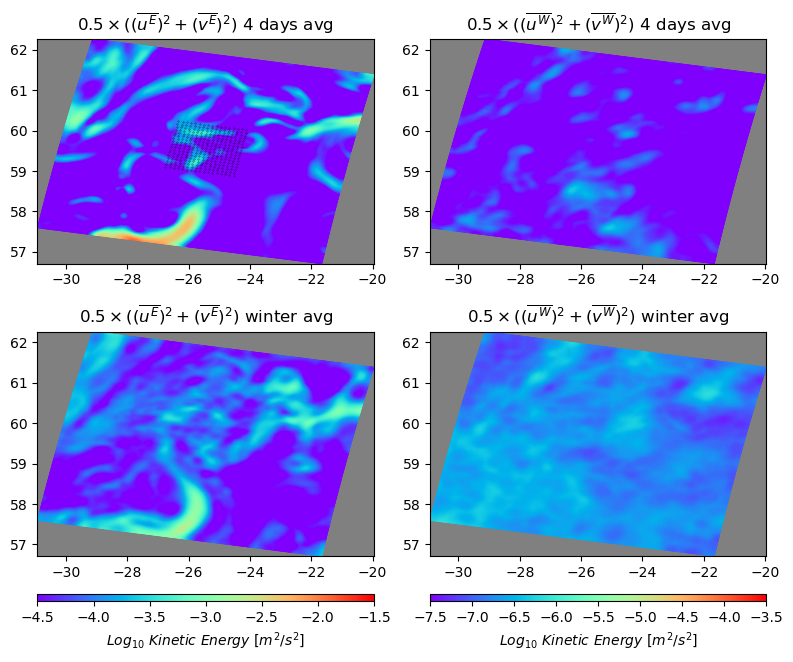

In [99]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig2 = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 2, figure=fig2)
ax2 = [
    [fig2.add_subplot(gs[0, 0]), fig2.add_subplot(gs[0, 1])],
    [fig2.add_subplot(gs[1, 0]), fig2.add_subplot(gs[1, 1])]
]

tin = 7 * 24 + 20

# 左上角子图
ax2[0][0].set_facecolor('grey')
cs1 = ax2[0][0].pcolormesh(lonr, latr, np.log(np.nanmean(ke_EG[:tin,:,:], axis=0)), 
                         shading='gouraud', cmap='rainbow', vmin=-4.5, vmax=-1.5)
ax2[0][0].scatter(lonp1,latp1,s=0.05,color='k')
ax2[0][0].set_title(r'$0.5 \times ((\overline{u^E})^{2} + (\overline{v^E})^{2})$ 4 days avg')

# 右上角子图
ax2[0][1].set_facecolor('grey')
cs2 = ax2[0][1].pcolormesh(lonr, latr, np.log(np.nanmean(ke_WG[:tin,:,:], axis=0)), 
                         shading='gouraud', cmap='rainbow', vmin=-7.5, vmax=-3.5)
ax2[0][1].set_title(r'$0.5 \times ((\overline{u^W})^{2} + (\overline{v^W})^{2})$ 4 days avg')

# 左下角子图
ax2[1][0].set_facecolor('grey')
cs3 = ax2[1][0].pcolormesh(lonr, latr, np.log(np.nanmean(ke_EG, axis=0)), 
                         shading='gouraud', cmap='rainbow', vmin=-4.5, vmax=-1.5)
ax2[1][0].set_title(r'$0.5 \times ((\overline{u^E})^{2} + (\overline{v^E})^{2})$ winter avg')

# 右下角子图
ax2[1][1].set_facecolor('grey')
cs4 = ax2[1][1].pcolormesh(lonr, latr, np.log(np.nanmean(ke_WG, axis=0)), 
                         shading='gouraud', cmap='rainbow', vmin=-7.5, vmax=-3.5)
ax2[1][1].set_title(r'$0.5 \times ((\overline{u^W})^{2} + (\overline{v^W})^{2})$ winter avg')

# 调整子图间距
plt.subplots_adjust(hspace=0.3, wspace=0.3, bottom=0.15)

# 为左下角子图添加色棒（位置更低）
cax1 = inset_axes(
    ax2[1][0],  # 父轴
    width="100%",  # 色棒宽度（相对于父轴宽度）
    height="3%",  # 色棒高度（相对于父轴高度）
    loc='lower center',  # 位置
    bbox_to_anchor=(0, -0.2, 1, 1),  # 锚点位置 (x, y, width, height) - y值更负
    bbox_transform=ax2[1][0].transAxes,  # 坐标系
    borderpad=0  # 边框填充
)
cbar1 = fig2.colorbar(cs3, cax=cax1, orientation='horizontal')
cbar1.set_label(r'$Log_{10} \ Kinetic \ Energy \ [m^{2}/s^{2}]$')

# 为右下角子图添加色棒（位置更低）
cax2 = inset_axes(
    ax2[1][1],  # 父轴
    width="100%",  # 色棒宽度（相对于父轴宽度）
    height="3%",  # 色棒高度（相对于父轴高度）
    loc='lower center',  # 位置
    bbox_to_anchor=(0, -0.2, 1, 1),  # 锚点位置 (x, y, width, height) - y值更负
    bbox_transform=ax2[1][1].transAxes,  # 坐标系
    borderpad=0  # 边框填充
)
cbar2 = fig2.colorbar(cs4, cax=cax2, orientation='horizontal')
cbar2.set_label(r'$Log_{10} \ Kinetic \ Energy \ [m^{2}/s^{2}]$')


plt.tight_layout()
plt.show()